In [2]:
import sys
sys.path.append("..")

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from services.utils_data import read_and_transform_data

/home/victor_muryn/ConEfuV2/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SUM_12_PATH = "../datasets_pre_defined/sum_12_fixed.jsonlines"
SUM_14_PATH = "../datasets_pre_defined/sum_14_final.jsonlines"
UNIQUE_SENTENCES_PATH = './raw_sentences/unique_lemma_sentences.jsonl'

## SUM 12

In [4]:
data_sum_12 = read_and_transform_data(SUM_12_PATH, homonym=True)

# sort by Ukrainian alphabet
alph = "АаБбВвГгҐґДдЕеЄєЖжЗзИиІіЇїЙйКкЛлМмНнОоПпРрСсТтУуФфХхЦцЧчШшЩщьЮюЯя"
data_sum_12 = data_sum_12.sort_values(by='lemma', key=lambda x: x.str.translate(str.maketrans({c: f"{i:02}" for i, c in enumerate(alph)})))
data_sum_12

,lemma,gloss,examples
0,абака,"[Чотирикутна плита, якою завершується верхня ч...",[Абака – плоска плита у верхній частині капіте...
1,абака,[Пальмоподібна багаторічна тропічна рослина ро...,[Кращий у світі канат – манільський – робиться...
2,аверс,"[Лицевий бік монети, медалі, медальйона ]",[На аверсі монети на фоні півкуль Землі зображ...
3,аверс,"[Прямий напрямок руху; використання механізму,...","[– Ви знаєте, що практично з часу введення в е..."
6,авізо,[Офіційне повідомлення про виконання розрахунк...,"[Особливо широко термін ""авізо"" застосовується..."
...,...,...,...
2458,підзол,"[Суміш попелу з вапном, яку використовують для...","[З будь-якого компонента, що містить вапно (ка..."
2457,підзол,"[Неродючий, бідний на поживні речовини ґрунт б...","[Підзоли розвиваються там, де протягом тривало..."
2459,підкачати,[За допомогою спортивних тренажерів і спеціаль...,[Підкачувати ноги й сідниці можна як на тренаж...
2460,підкачати,"[Підгортаючи, піднімаючи краї, робити коротшим...",[Нараз він схватився зі свого місця і почав як...


In [5]:
# unique lemmas
data_sum_12.lemma.nunique()

1153

count    2414.000000
mean        5.255592
std         6.989463
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        81.000000
dtype: float64


<Axes: >

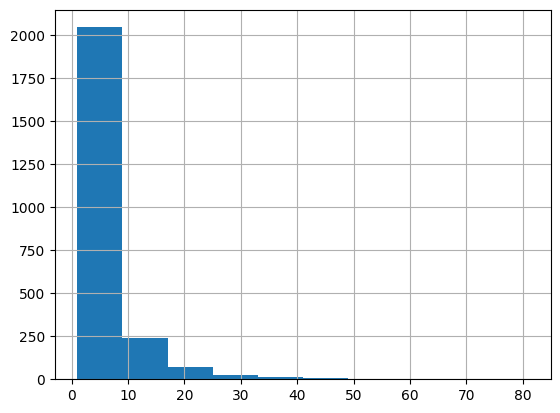

In [6]:
n_examples_per_lemma = data_sum_12.apply(lambda x: len(x["examples"]), axis=1)
print(n_examples_per_lemma.describe())
n_examples_per_lemma.hist()

## SUM 14

In [7]:
data_sum_14 = read_and_transform_data(SUM_14_PATH, homonym=True)

# sort by Ukrainian alphabet
alph = "АаБбВвГгҐґДдЕеЄєЖжЗзИиІіЇїЙйКкЛлМмНнОоПпРрСсТтУуФфХхЦцЧчШшЩщьЮюЯя"
data_sum_14 = data_sum_14.sort_values(by='lemma', key=lambda x: x.str.translate(str.maketrans({c: f"{i:02}" for i, c in enumerate(alph)})))
data_sum_14

,lemma,gloss,examples
0,абака,"[Чотирикутна плита, якою завершується верхня ч...",[Абака – плоска плита у верхній частині капіте...
1,абака,[Пальмоподібна багаторічна тропічна рослина ро...,[Кращий у світі канат – манільський – робиться...
2,аверс,"[Лицевий бік монети, медалі, медальйона ]",[На аверсі монети на фоні півкуль Землі зображ...
3,аверс,"[Прямий напрямок руху; використання механізму,...","[– Ви знаєте, що практично з часу введення в е..."
6,авізо,[Офіційне повідомлення про виконання розрахунк...,"[Особливо широко термін ""авізо"" застосовується..."
...,...,...,...
3037,празелень,[Синювато-зелена фарба чи колір],"[В старім порту солоний вітер віє, Повзе по му..."
3040,прас,[Прес],"[Оце в мене сир під прасом, Має мій милий близ..."
3039,прас,[Праска],"[Нагрівся прас. Прасувала, клала до складочки ..."
3042,прасувати,"[Надмірно або жадібно їсти, споживати, Сильно ...","[– Таких панів, що бублик у руці держить, а чо..."


we have up to letter П

In [8]:
# unique lemmas
data_sum_14.lemma.nunique()

1464

count    3071.000000
mean        5.197330
std         7.147456
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        81.000000
dtype: float64


<Axes: >

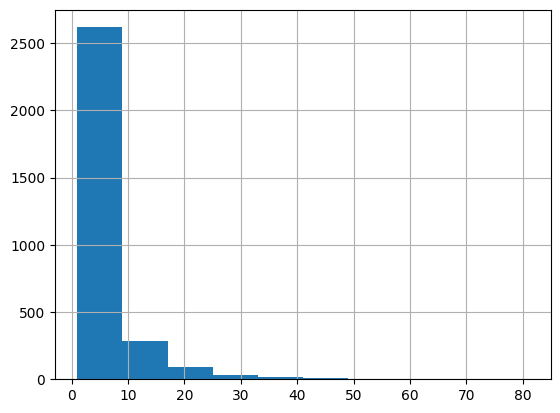

In [9]:
n_examples_per_lemma = data_sum_14.apply(lambda x: len(x["examples"]), axis=1)
print(n_examples_per_lemma.describe())
n_examples_per_lemma.hist()

## UberText 2.0

In [10]:
with open(UNIQUE_SENTENCES_PATH, 'r') as f:
    data_ubertext = [json.loads(line) for line in f]

In [11]:
lemmas = set([item['lemma'] for item in data_ubertext])
len(lemmas)

1362

In [12]:
lemmas_without_sentences = set(data_sum_14['lemma'].unique()) - lemmas
len(lemmas_without_sentences)

102

In [13]:
# find вара in data_sum_14
data_sum_14[data_sum_14['lemma'] == 'вара']

,lemma,gloss,examples
254,вара,[Міра довжини в багатьох країнах Латинської Ам...,[Величина вари – від 80 до 110 см]
253,вара,[Геть],"[Вара, вара з-під віконця, хлопче, Чи ласка па..."


In [14]:
lemmas_without_sentences

{'безвікий',
 'бучильний',
 'вибучувати',
 'волохи',
 'візирування',
 'візирувати',
 'віолан',
 'віолент',
 'віридин',
 'вітритися',
 'десцендент',
 'дигіталізовувати',
 'докувати',
 'дометати',
 'допаювати',
 'дотопити',
 'дрібушки',
 'емітувальний',
 'заляскотати',
 'запустувати',
 'зашліхтовувати',
 'кондиціонал',
 'ланцювати',
 'лесотка',
 'лесувати',
 'мелопластика',
 'миколайчики',
 'надвозити',
 'назолити',
 'накупати',
 'накушувати',
 'налигнути',
 'налініювати',
 'намулитися',
 'настьобати',
 'нутряк',
 'обезкрилити',
 'обповзати',
 'оброчник',
 'одвір',
 'палильник',
 'перекалатати',
 'перекантовувати',
 'перелініювати',
 'переметати',
 "переп'ясти",
 'перепарувати',
 'пересмикати',
 'перестиглість',
 'перестьобати',
 'перетіпати',
 'по-словенському',
 'повиглядати',
 'повириватися',
 'повиходжувати',
 'повмазувати',
 'повшивати',
 'погикати',
 'позавиватися',
 'позаголювати',
 'позамулюватися',
 'позамішувати',
 'позапливати',
 'позапускатися',
 'позасікати',
 'позатаскувати

count    1.362000e+03
mean     8.815098e+03
std      5.674140e+04
min      1.000000e+00
25%      2.400000e+01
50%      2.175000e+02
75%      1.536000e+03
max      1.309977e+06
dtype: float64


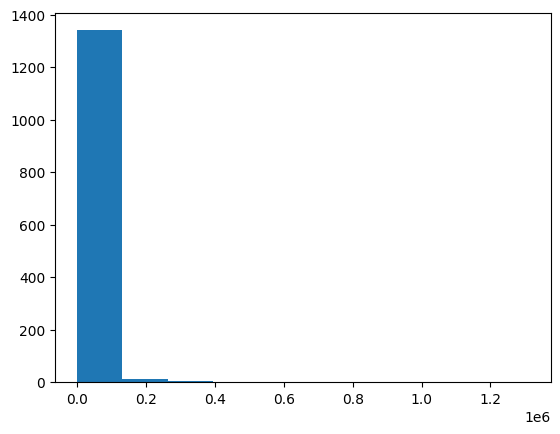

In [15]:
sentences_per_lemma = pd.Series([len(item['sentences']) for item in data_ubertext])
print(sentences_per_lemma.describe())

plt.hist(sentences_per_lemma);

In [16]:
# find where len(sentences) > 1000
long_lemmas = [item for item in data_ubertext if len(item['sentences']) > 1000]
# sort by len(sentences)
long_lemmas = sorted(long_lemmas, key=lambda x: len(x['sentences']), reverse=True)
len(long_lemmas)

417

In [26]:
total_sentences = sum([len(item['sentences']) for item in data_ubertext])
top_20_sentences = sum([len(item['sentences']) for item in long_lemmas[:20]])
print(f"Total sentences in long lemmas: {total_sentences:,}")
print(f"Top 20 lemmas cover {top_20_sentences:,} sentences, which is {top_20_sentences / total_sentences:.2%} of all sentences.")

print()
for item in long_lemmas[:20]:
    print(f"{item['lemma']:<13}: {len(item['sentences']):,} sentences")

Total sentences in long lemmas: 12,006,163
Top 20 lemmas cover 6,862,605 sentences, which is 57.16% of all sentences.

мати         : 1,309,977 sentences
весь         : 1,030,147 sentences
місто        : 703,032 sentences
зараз        : 436,165 sentences
кілька       : 344,082 sentences
держава      : 334,304 sentences
початок      : 311,643 sentences
передавати   : 274,936 sentences
перебувати   : 243,282 sentences
лютий        : 223,693 sentences
відповідний  : 183,573 sentences
акція        : 178,009 sentences
планувати    : 175,110 sentences
година       : 172,663 sentences
план         : 167,193 sentences
банк         : 166,375 sentences
око          : 158,542 sentences
директор     : 151,806 sentences
орган        : 149,650 sentences
зона         : 148,423 sentences


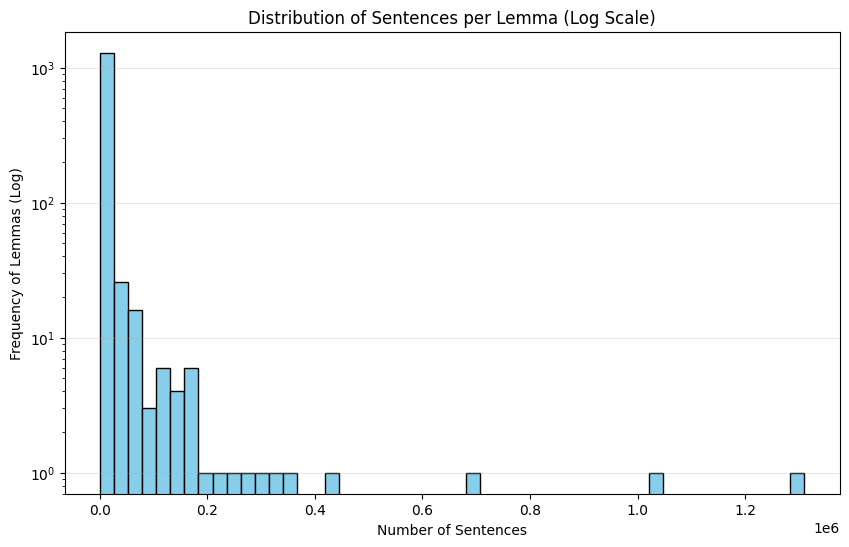

In [18]:
# Prep the data
counts = [len(item['sentences']) for item in data_ubertext]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=50, log=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentences per Lemma (Log Scale)')
plt.xlabel('Number of Sentences')
plt.ylabel('Frequency of Lemmas (Log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

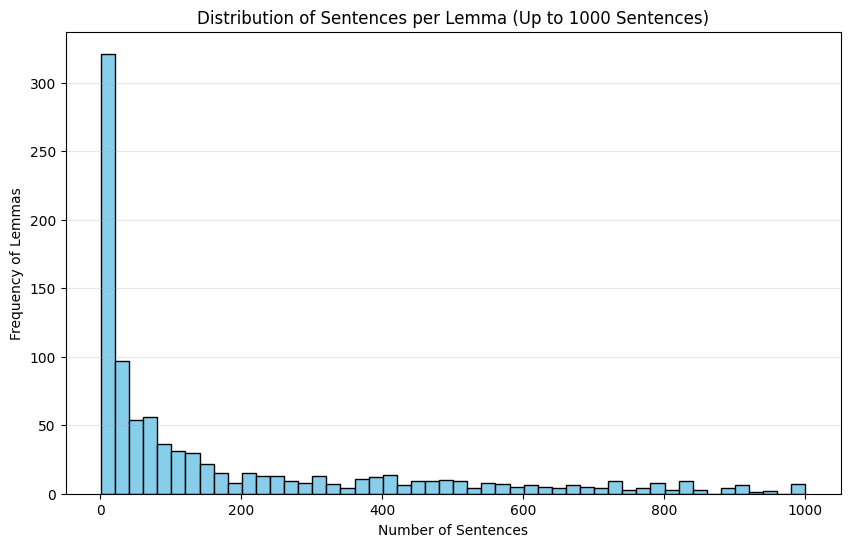

In [19]:
# Prep the data
counts = [len(item['sentences']) for item in data_ubertext if len(item['sentences']) <= 1000]

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentences per Lemma (Up to 1000 Sentences)')
plt.xlabel('Number of Sentences')
plt.ylabel('Frequency of Lemmas')
plt.grid(axis='y', alpha=0.3)
plt.show()

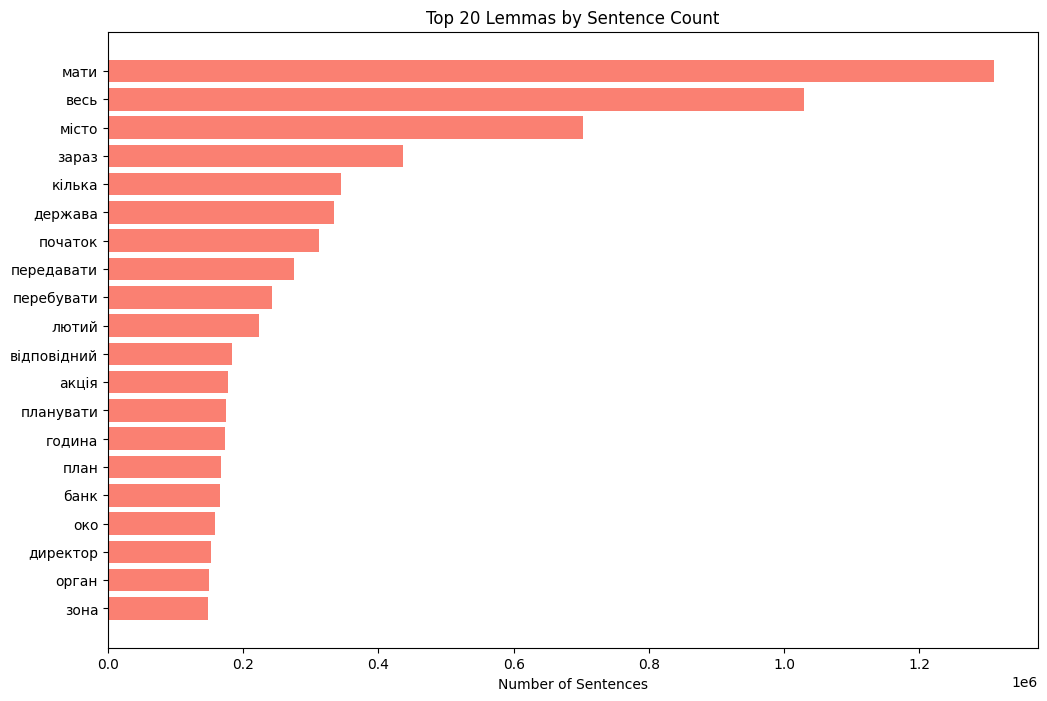

In [20]:
# Sort and grab top 20
top_lemmas = sorted(data_ubertext, key=lambda x: len(x['sentences']), reverse=True)[:20]
labels = [item['lemma'] for item in top_lemmas]
values = [len(item['sentences']) for item in top_lemmas]

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='salmon')
plt.title('Top 20 Lemmas by Sentence Count')
plt.xlabel('Number of Sentences')
plt.show()

In [21]:
df_counts = pd.Series(counts)
print(df_counts.describe(percentiles=[.25, .5, .75, .9, .95, .99]))

count     945.000000
mean      178.845503
std       244.512069
min         1.000000
25%        10.000000
50%        61.000000
75%       256.000000
90%       577.400000
95%       757.200000
99%       922.240000
max      1000.000000
dtype: float64


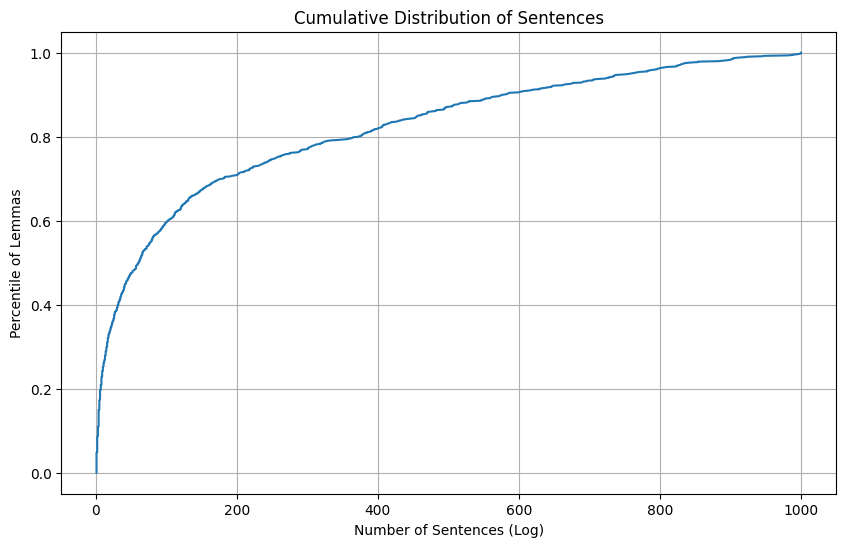

In [22]:
sorted_counts = np.sort(counts)
p = np.arange(len(sorted_counts)) / float(len(sorted_counts) - 1)

plt.figure(figsize=(10, 6))
plt.plot(sorted_counts, p)
# plt.xscale('log') # Crucial because of your 10k outliers
plt.title('Cumulative Distribution of Sentences')
plt.xlabel('Number of Sentences (Log)')
plt.ylabel('Percentile of Lemmas')
plt.grid(True)
plt.show()

In [23]:
sum(min(len(item['sentences']), 100) for item in data_ubertext)

94823